In [1]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product
from jax.nn import relu
import jax.numpy as jnp
from jax.typing import ArrayLike
import jax
from WMSE import WMSE, WMSE_metric


jax.config.update("jax_enable_x64", False)

#### graphical
import matplotlib.pyplot as plt
import corner
import matplotlib

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers
from matplotlib.gridspec import GridSpec
##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="0"

physical_devices = tf.config.list_physical_devices("GPU") 

tf.config.experimental.set_memory_growth(physical_devices[0], True)

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

modelpath = '/home/hatte/M4/models'

2025-08-07 15:28:48.846272: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754576928.858127 3112816 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754576928.861901 3112816 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Current GPU usage:
 - GPU0: 0B



I0000 00:00:1754576930.786114 3112816 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2083 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


In [2]:
df_full = pd.read_hdf('../grids/Chiara-dnufit.hdf5', key='df') ## edit for your grid!!

df_full['logLPhot'] = np.log10(df_full['LPhot'])
df_full['logAge'] = np.log10(df_full['age'])
df_full['lognumax'] = np.log10(df_full['numax']*3090)
df_full['logdnufit'] = np.log10(df_full['dnufit']*135)

#### define inputs
inputs = ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe']

#### define outputs
classical_outputs = ['FeH', 'logLPhot', 'Teff']
astero_outputs = ['lognumax', 'logdnufit'] # 10 modes for now

outputs = classical_outputs+astero_outputs

df = df_full[inputs+outputs]

df_norm = (df - df.min())/(df.max() - df.min())

## check df_norm.describe looks reasonable (min=0, max=1):
df_norm.describe()

,massini,zini,yini,alphaMLT,logAge,eta,alphaFe,FeH,logLPhot,Teff,lognumax,logdnufit
count,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06
mean,5.320517e-01,1.169785e-01,4.801320e-01,5.207879e-01,5.600889e-01,4.995957e-01,5.104678e-01,5.510095e-01,6.590481e-01,1.893095e-01,3.204782e-01,3.065330e-01
std,2.741396e-01,1.503168e-01,2.866208e-01,2.874298e-01,2.294823e-01,2.886541e-01,3.224309e-01,2.766927e-01,1.768257e-01,6.669141e-02,2.203469e-01,2.354566e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.050000e-01,1.490123e-02,2.313656e-01,2.751358e-01,3.773491e-01,2.494505e-01,2.500000e-01,3.284310e-01,5.532432e-01,1.458403e-01,1.430966e-01,1.167102e-01
50%,5.362500e-01,5.506925e-02,4.703010e-01,5.304316e-01,5.534359e-01,4.997558e-01,5.000000e-01,5.743831e-01,6.935266e-01,1.897028e-01,2.651610e-01,2.447980e-01
75%,7.675000e-01,1.620700e-01,7.242537e-01,7.715646e-01,7.451413e-01,7.497558e-01,7.500000e-01,7.868256e-01,7.945543e-01,2.266111e-01,4.502288e-01,4.444605e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [3]:
seed = 42

df_train = df_norm.sample(frac=0.95, random_state=seed)
df_test = df_norm.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.05, random_state=seed)

print("Training set: ", len(df_train_inputs))
print("Validation set: ", len(df_val_inputs))
print("Test set: ", len(df_test))

Training set:  6754081
Validation set:  355478
Test set:  374187


In [4]:
######## define architecture:
n_dense_layers = 6

dense_layer_units = 128

Nepochs = 100000

learning_rate = 0.0001

model_name = 'logAge-logLPhot-lognumax-logdnufit-exponent-6e-6-Adam'

loss_func = 'WMSE'
###### Checkpointing

custom_objects =  {'WMSE':WMSE_metric}

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

model= tf.keras.models.load_model(checkpoint_dir, custom_objects = custom_objects)

In [5]:
def unnorm(df_norm, df_min, df_max):
    df_unnorm = (df_norm*(df_max-df_min)) + df_min
    return df_unnorm

preds_norm = model(np.array(df_test[inputs]))

df_preds_norm = pd.DataFrame(preds_norm, columns=outputs)
df_preds_unnorm = unnorm(df_preds_norm, df[outputs].min(), df[outputs].max())

df_test_unnorm = unnorm(df_test, df.min(), df.max())

df_test_unnorm['LPhot'] = 10**df_test_unnorm['logLPhot']
df_preds_unnorm['LPhot'] = 10**df_preds_unnorm['logLPhot']

In [6]:
##color maps
from pypalettes import load_cmap
Peach = load_cmap('Peach', cmap_type = 'continuous')

Concha = load_cmap('Concha', cmap_type = 'continuous')

Indigo = matplotlib.colors.LinearSegmentedColormap.from_list('custom purples', load_cmap('Magenta', cmap_type = 'continuous').colors[::-1], N=256)

Burg = load_cmap('Burg', cmap_type = 'continuous')

DM = load_cmap('DarkMint', cmap_type = 'continuous')

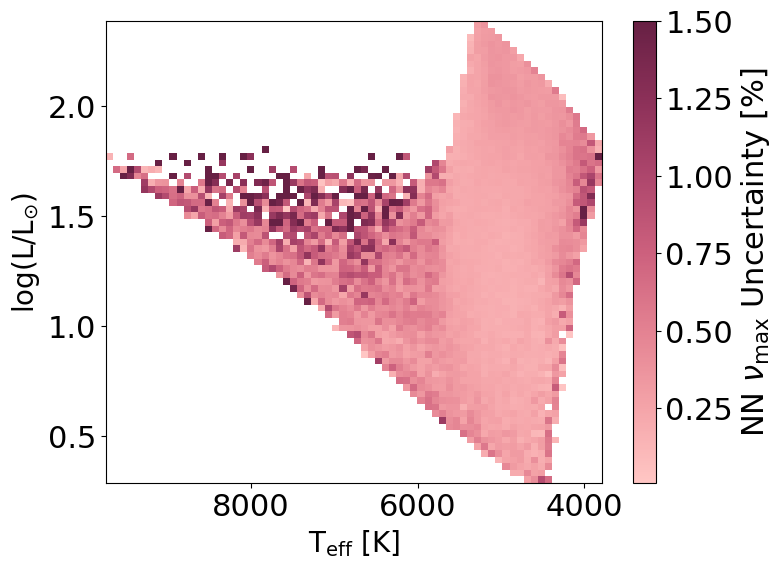

In [7]:

matplotlib.rcParams.update({'font.size': 22})

from scipy.stats import binned_statistic_2d
import matplotlib


# Example data: x, y coordinates and associated z values
 # Your z values (could be anything)

# Define the grid for binning
gridsize = 70  # Size of the bins (adjust this for more or fewer bins)

off_numax = 100*(10**df_test_unnorm['lognumax'].values - 10**df_preds_unnorm['lognumax'].values)/(10**df_test_unnorm['lognumax'].values)
teff_test = df_test_unnorm['Teff'].values
logL_test =  df_test_unnorm['logLPhot'].values

# Use binned_statistic_2d to calculate the average z value in each bin
#stat, xedges, yedges, binnumber = binned_statistic_2d(
#    teff_test,  logL_test, off_numax, statistic=lambda y: 0.25*(np.quantile(y, 0.16)**2 + np.quantile(y, 0.84)**2)**0.5, bins=gridsize
#)

stat, xedges, yedges, binnumber = binned_statistic_2d(
    teff_test,  logL_test, off_numax, statistic=lambda y: 0.25*(np.quantile(y, 0.16)**2 + np.quantile(y, 0.84)**2)**0.5, bins=gridsize
)

# Replace NaNs (empty bins) with 0 (or any other value you'd prefer)
#stat = np.nan_to_num(stat, nan=0)



# Plot the results using pcolormesh (this gives a grid-like appearance)
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()
X, Y = np.meshgrid(xedges, yedges)  # Create a mesh grid for plotting
pcm = plt.pcolormesh(X, Y, stat.T, cmap=Burg, shading='auto', vmax = 1.5)
plt.colorbar(pcm, label=r'NN $\nu_{\mathrm{max}}$ Uncertainty [%]',)  # Colorbar to show the average z values
plt.xlabel(r'T$_{\mathrm{eff}}$ [K]', fontsize = 20)
plt.ylabel(r'log(L/L$_{\odot}$)', fontsize = 20)
ax.invert_xaxis()

#plt.savefig(f'../figs/hexplot-numax-frac-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.png', dpi = 150, bbox_inches = 'tight', pad_inches = 2)
plt.show()


In [14]:
np.max(10**df['logAge'])

np.float64(20000.000000000004)

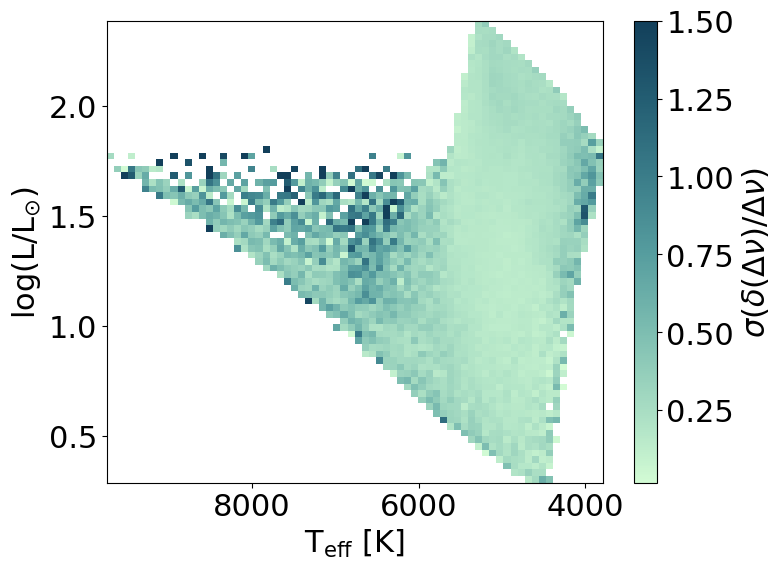

In [8]:
# Define the grid for binning
  # Size of the bins (adjust this for more or fewer bins)





off_dnu = 100*(10**df_test_unnorm['logdnufit'].values - 10**df_preds_unnorm['logdnufit'].values)/(10**df_test_unnorm['logdnufit'].values)
teff_test = df_test_unnorm['Teff'].values
logL_test =  df_test_unnorm['logLPhot'].values

# Use binned_statistic_2d to calculate the average z value in each bin
stat, xedges, yedges, binnumber = binned_statistic_2d(
    teff_test,  logL_test, off_dnu, statistic=lambda y: 0.25*(np.quantile(y, 0.16)**2 + np.quantile(y, 0.84)**2)**0.5, bins=gridsize
)

# Replace NaNs (empty bins) with 0 (or any other value you'd prefer)
#stat = np.nan_to_num(stat, nan=0)
#stat[stat == 0] = np.nan
# Plot the results using pcolormesh (this gives a grid-like appearance)
plt.figure(figsize=(8, 6))
ax = plt.gca()
X, Y = np.meshgrid(xedges, yedges)  # Create a mesh grid for plotting
pcm = plt.pcolormesh(X, Y, stat.T, cmap=DM, shading='auto', vmax = 1.5)
plt.colorbar(pcm, label=r'$\sigma(\delta( \Delta \nu)/\Delta \nu)$')  # Colorbar to show the average z values
plt.xlabel(r'T$_{\mathrm{eff}}$ [K]')
plt.ylabel(r'log(L/L$_{\odot}$)')
ax.invert_xaxis()
plt.savefig(f'../figs/hexplot-dnu-frac-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.png', bbox_inches = 'tight')
plt.show()

np.float64(0.7864262365006544)

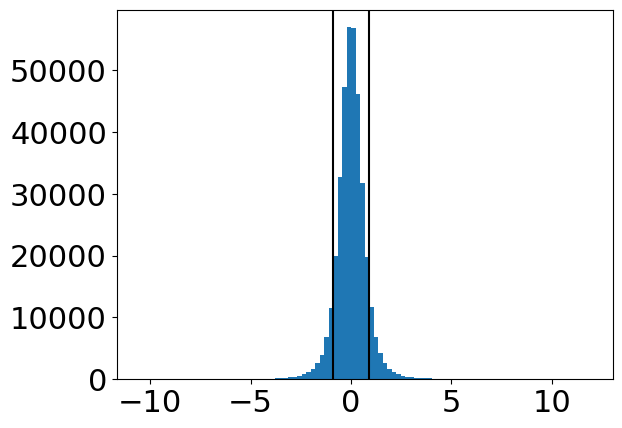

In [9]:
plt.hist(off_dnu, bins = 100)
plt.axvline(-0.9, color = 'black')
plt.axvline(0.9, color = 'black')
np.std(off_dnu)

In [12]:
plt.scatter(df_test['Teff'], df_test['logdnufit'])

KeyError: 'logdnufit'

np.float64(1.1038484714222632)

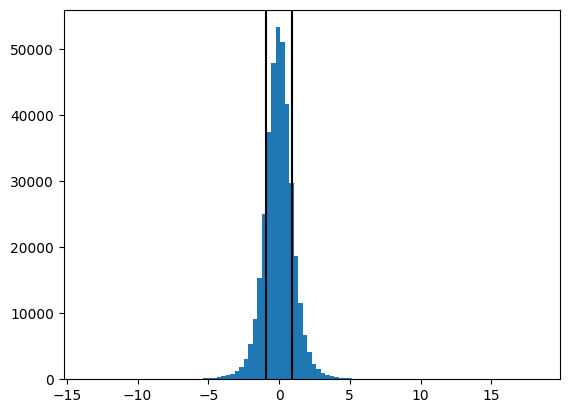

In [21]:
off_LPhot = 100*(10**df_test_unnorm['logLPhot'].values - 10**df_preds_unnorm['logLPhot'].values)/(10**df_test_unnorm['logLPhot'].values)

plt.hist(off_LPhot, bins = 100)
plt.axvline(-0.9, color = 'black')
plt.axvline(0.9, color = 'black')
np.std(off_LPhot)

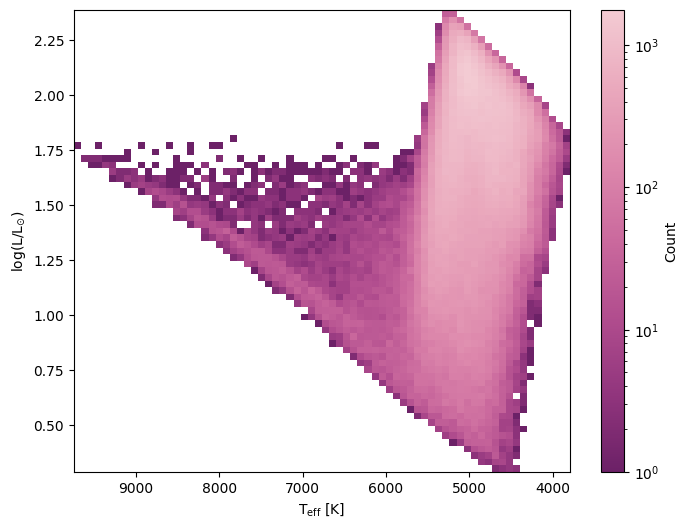

In [9]:



stat, xedges, yedges, binnumber = binned_statistic_2d(
    teff_test,  logL_test, off_numax, statistic='count', bins=gridsize
)

# Replace NaNs (empty bins) with 0 (or any other value you'd prefer)
stat[stat == 0] = np.nan

# Plot the results using pcolormesh (this gives a grid-like appearance)
plt.figure(figsize=(8, 6))
ax = plt.gca()
X, Y = np.meshgrid(xedges, yedges)  # Create a mesh grid for plotting
pcm = plt.pcolormesh(X, Y, stat.T, cmap=Indigo, shading='auto', norm = matplotlib.colors.LogNorm())
plt.colorbar(pcm, label=r'Count', )  # Colorbar to show the average z values
plt.xlabel(r'T$_{\mathrm{eff}}$ [K]')
plt.ylabel(r'log(L/L$_{\odot}$)')
ax.invert_xaxis()
#plt.savefig(f'../figs/hexplot-count-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.png', bbox_inches = 'tight')


In [10]:
LG.colors[::-1]

NameError: name 'LG' is not defined